In [ ]:
# Import libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

from sklearn.svm import SVC

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving ML-CaseStudy2-Dataset.csv to ML-CaseStudy2-Dataset.csv


In [ ]:
df = pd.read_csv('ML-CaseStudy2-Dataset.csv')

df.head()

,Employee_ID,Employee_Name,Age,Years_of_Experience,Monthly_Salary,Working_Hours_Per_Day,Projects_Handled,Job_Satisfaction,Department,City,Performance_Score,Attrition_Flag
0,11de2b9e-2148-4a1e-951b-1323d8f5f941,Austin Rodriguez,59.0,36,25860.0,11,13,6.37,sales,Pune,26.50,1
1,816703b6-7f5c-4511-8bf3-ace06d28333c,Stephanie Salazar,31.0,4,69131.0,11,8,6.86,IT,Mumbai,43.23,1
2,d10e1435-380e-4727-bab0-d1db39ea5e9e,Mrs. Jaclyn Chavez,22.0,0,87955.0,9,2,2.64,Human Resource,Mumbai,43.28,1
3,d8456859-9280-4bb0-a772-78952813e838,Susan Quinn,42.0,14,131970.0,13,12,9.76,sales,Chennai,77.60,1
4,791f7234-a526-4b85-adaa-70b4b01cbad8,Matthew Nelson,35.0,13,92435.0,10,4,6.33,sales,Hyderabad,58.22,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5050 entries, 0 to 5049
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Employee_ID            5050 non-null   object 
 1   Employee_Name          5050 non-null   object 
 2   Age                    4950 non-null   float64
 3   Years_of_Experience    5050 non-null   int64  
 4   Monthly_Salary         4949 non-null   float64
 5   Working_Hours_Per_Day  5050 non-null   int64  
 6   Projects_Handled       5050 non-null   int64  
 7   Job_Satisfaction       4949 non-null   float64
 8   Department             5050 non-null   object 
 9   City                   5050 non-null   object 
 10  Performance_Score      5050 non-null   float64
 11  Attrition_Flag         5050 non-null   int64  
dtypes: float64(4), int64(4), object(4)
memory usage: 473.6+ KB


In [ ]:
print("Rows And Columns:", df.shape)

Rows And Columns: (5050, 12)


In [ ]:
df.isnull().sum()

,0
Employee_ID,0
Employee_Name,0
Age,100
Years_of_Experience,0
Monthly_Salary,101
Working_Hours_Per_Day,0
Projects_Handled,0
Job_Satisfaction,101
Department,0
City,0


In [ ]:
df.duplicated().any()

np.True_

In [ ]:
df.duplicated().sum()

np.int64(46)

In [ ]:
data1 = df.drop_duplicates()

In [ ]:
#check missing values
data1.isnull().any()

,0
Employee_ID,False
Employee_Name,False
Age,True
Years_of_Experience,False
Monthly_Salary,True
Working_Hours_Per_Day,False
Projects_Handled,False
Job_Satisfaction,True
Department,False
City,False


In [ ]:
#Indexing columns
df = data1.isnull().sum().reset_index()
#Rename column
df.columns = ['column', 'null_records']
#Create new colums and gind out null value percentage
df['% null_records'] = (df['null_records']/200)*100
df

,column,null_records,% null_records
0,Employee_ID,0,0.0
1,Employee_Name,0,0.0
2,Age,100,50.0
3,Years_of_Experience,0,0.0
4,Monthly_Salary,100,50.0
5,Working_Hours_Per_Day,0,0.0
6,Projects_Handled,0,0.0
7,Job_Satisfaction,100,50.0
8,Department,0,0.0
9,City,0,0.0


In [ ]:
Age_mean = data1['Age'].mean()
Age_mean
data1['Age'] = data1['Age'].fillna(Age_mean)

In [ ]:
Monthly_Salary_mean = data1['Monthly_Salary'].mean()
Monthly_Salary_mean
data1['Monthly_Salary'] =data1['Monthly_Salary'].fillna(Monthly_Salary_mean)

In [ ]:
Job_Satisfaction_mean =data1['Job_Satisfaction'].mean()
Job_Satisfaction_mean
data1['Job_Satisfaction'] = data1['Job_Satisfaction'].fillna(Job_Satisfaction_mean)

In [ ]:
data1['Attrition_Flag'].value_counts()

,count
Attrition_Flag,
1,2936
0,2068


In [ ]:
data1.columns = data1.columns.str.strip()

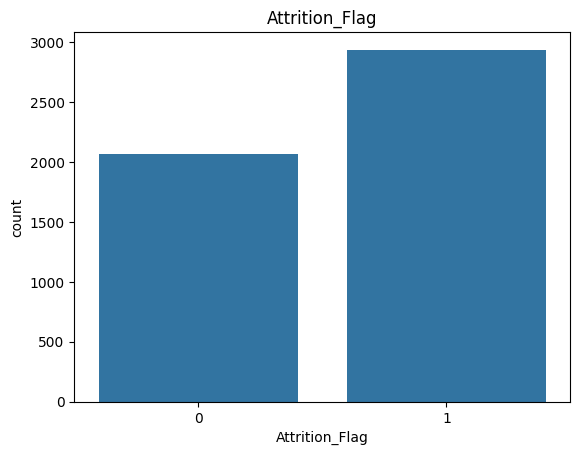

In [ ]:
sns.countplot(x='Attrition_Flag', data=data1)
plt.title('Attrition_Flag')
plt.show()

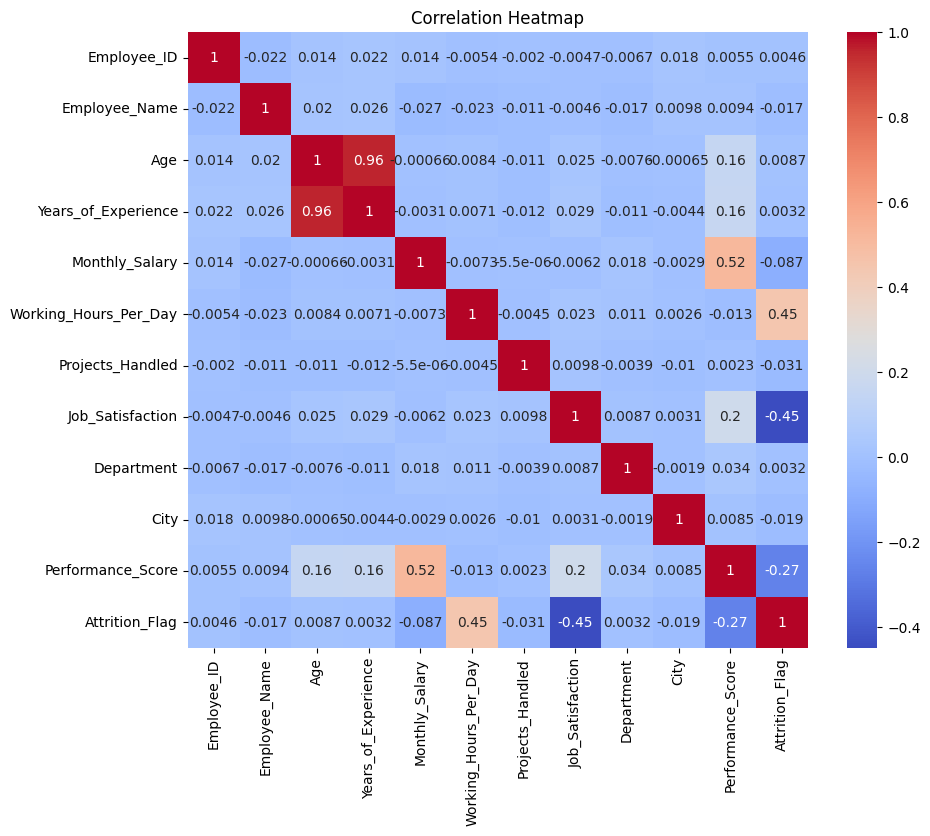

In [ ]:
plt.figure(figsize=(10, 8))

sns.heatmap(data1.select_dtypes(include=['number']).corr(),
            annot=True,
            cmap='coolwarm')

plt.title('Correlation Heatmap')
plt.show()

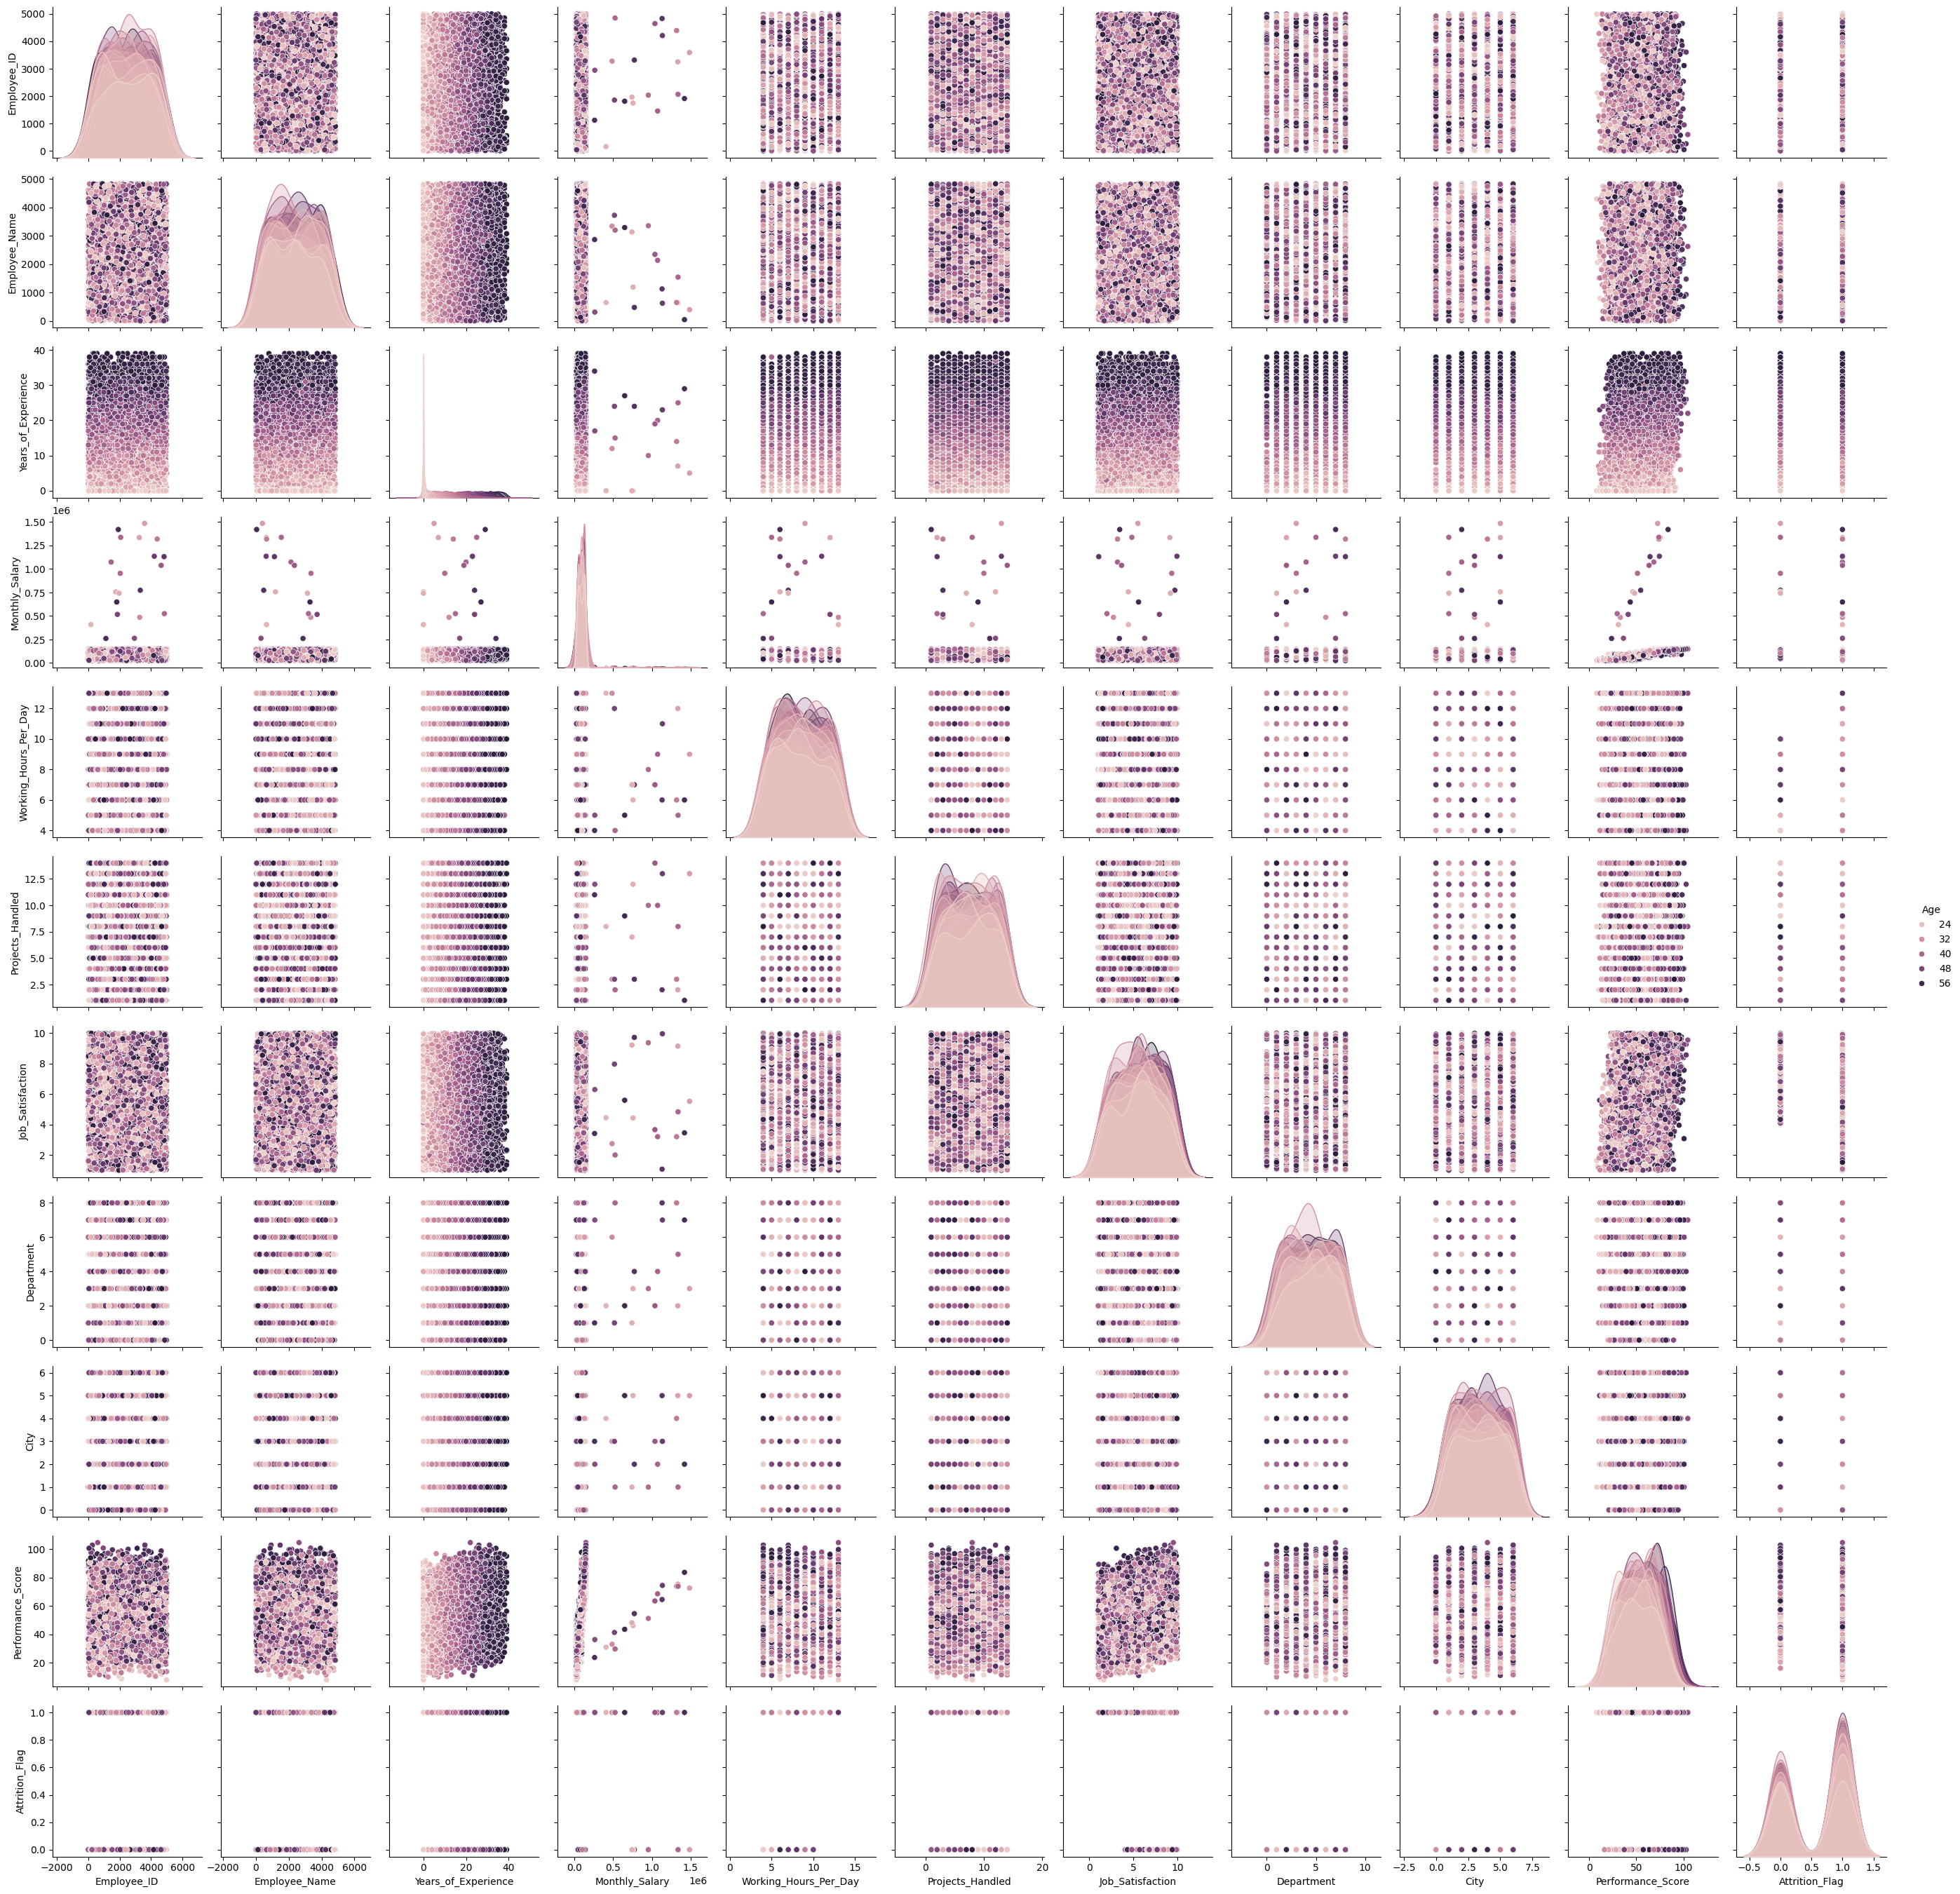

In [ ]:
sns.pairplot(data1, hue='Age')
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data1['Employee_ID'] = le.fit_transform(data1['Employee_ID'])
data1['Employee_Name'] = le.fit_transform(data1['Employee_Name'])
data1['Department'] = le.fit_transform(data1['Department'])
data1['City'] = le.fit_transform(data1['City'])

In [ ]:
X = data1[['Age',
        'Years_of_Experience',
        'Monthly_Salary',
        'Working_Hours_Per_Day',
        'Projects_Handled',
        'Job_Satisfaction',
        'Department',
        'City']]

y = data1['Attrition_Flag']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [ ]:
y_pred = knn.predict(X_test)
print(y_pred)

[1 1 1 ... 1 1 1]


In [ ]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[385  44]
 [ 74 498]]


In [ ]:
from sklearn.model_selection import GridSearchCV


In [ ]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf','linear']
}

In [ ]:
grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=2 )

In [ ]:
grid.fit(X_train, y_train)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.6s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.6s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.6s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.6s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.6s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.2s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.2s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.2s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.2s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.2s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.3s
[CV] END .......................C=0.1, gamma=0.

GridSearchCV(estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100], 'gamma': [1, 0.1, 0.01, 0.001],
                         'kernel': ['rbf', 'linear']},
             verbose=2)

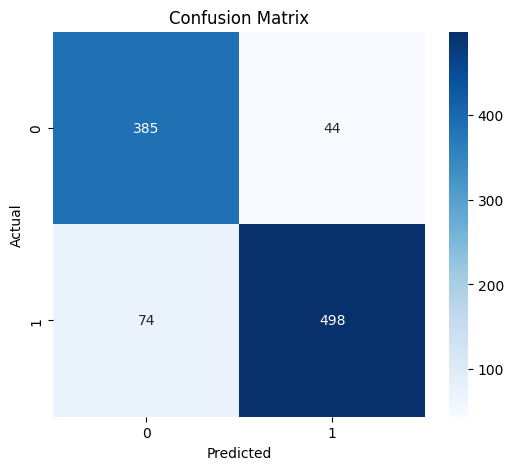

In [ ]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87       429
           1       0.92      0.87      0.89       572

    accuracy                           0.88      1001
   macro avg       0.88      0.88      0.88      1001
weighted avg       0.88      0.88      0.88      1001



In [ ]:
accuracy_scores = []

for i in range(1, 21):

    model = KNeighborsClassifier(n_neighbors=i)

    model.fit(X_train, y_train)

    pred_i = model.predict(X_test)

    score = accuracy_score(y_test, pred_i)

    accuracy_scores.append(score)

print(accuracy_scores)

[0.8711288711288712, 0.8401598401598401, 0.8821178821178821, 0.8681318681318682, 0.8911088911088911, 0.8831168831168831, 0.8951048951048951, 0.8871128871128872, 0.8851148851148851, 0.8911088911088911, 0.8871128871128872, 0.8941058941058941, 0.8921078921078921, 0.8971028971028971, 0.8931068931068931, 0.9000999000999002, 0.8941058941058941, 0.9000999000999002, 0.9050949050949051, 0.906093906093906]


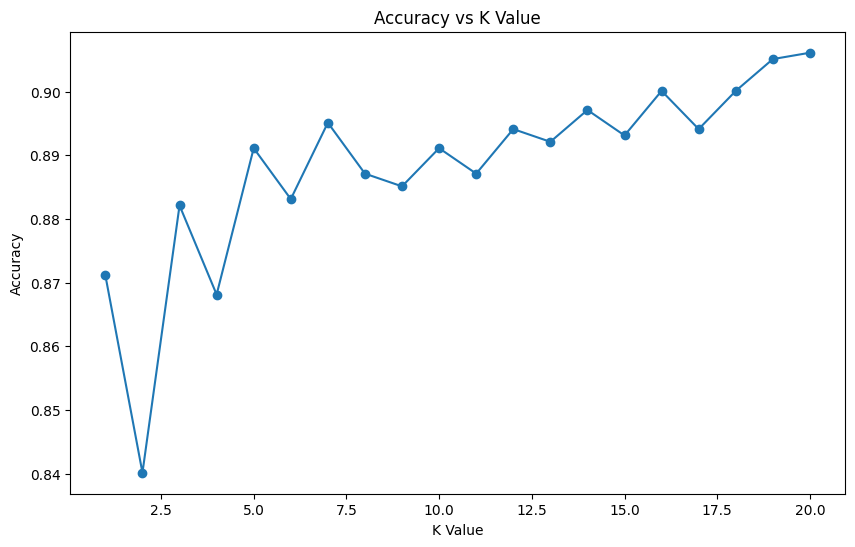

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, 21), accuracy_scores, marker='o', linestyle='-')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.title('Accuracy vs K Value')

plt.show()

In [ ]:
final_model = KNeighborsClassifier(n_neighbors=11)
final_model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=11)

In [ ]:
final_pred = final_model.predict(X_test)
print(final_pred)

[1 1 1 ... 1 0 1]


In [ ]:
final_accuracy = accuracy_score(y_test, final_pred)
print("Final Accuracy:", final_accuracy)

Final Accuracy: 0.8871128871128872


In [ ]:
data1

,Employee_ID,Employee_Name,Age,Years_of_Experience,Monthly_Salary,Working_Hours_Per_Day,Projects_Handled,Job_Satisfaction,Department,City,Performance_Score,Attrition_Flag
0,387,462,59.0,36,25860.0,11,13,6.37,8,6,26.50,1
1,2502,4350,31.0,4,69131.0,11,8,6.86,4,5,43.23,1
2,4071,3577,22.0,0,87955.0,9,2,2.64,3,5,43.28,1
3,4204,4440,42.0,14,131970.0,13,12,9.76,8,2,77.60,1
4,2350,3233,35.0,13,92435.0,10,4,6.33,8,4,58.22,0
...,...,...,...,...,...,...,...,...,...,...,...,...
4999,4689,801,48.0,20,27053.0,8,1,5.49,1,3,28.42,1
5029,1782,3378,33.0,4,33199.0,7,14,6.77,0,2,21.77,1
5042,1514,648,46.0,24,120742.0,6,4,6.81,8,5,73.17,0
5045,4162,126,57.0,35,79497.0,6,7,9.42,2,3,57.36,0


In [ ]:
new_data = [[28, 5, 65000, 9, 6, 7.25, 3, 4]]
new_data_scaled = scaler.transform(new_data)
prediction = final_model.predict(new_data_scaled)
print( prediction)

[0]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
if prediction[0] == 0:
  print("Prediction is : Female")
elif prediction[0] == 1:
  print("Prediction is : Male")

Prediction is : Female
